#Libraries

In [ ]:
# Install required packages if not already installed
!pip install numpy pandas matplotlib seaborn scipy statsmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, ttest_ind, chi2_contingency, pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

##MIMIC-III Style Data
We'll create a dataset that resembles MIMIC-III structure with:

- Patient demographics
- Vital signs
- Lab results
- Hospital stay information

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Number of patients
n_patients = 1000

# Generate patient demographics
patients = pd.DataFrame({
    'patient_id': range(1, n_patients + 1),
    'age': np.random.normal(65, 15, n_patients).clip(18, 95).astype(int),
    'gender': np.random.choice(['M', 'F'], n_patients, p=[0.55, 0.45]),
    'weight_kg': np.random.normal(75, 15, n_patients).clip(40, 150).round(1),
    'height_cm': np.random.normal(170, 10, n_patients).clip(140, 200).round(1)
})

# Generate admission data
admission_types = ['EMERGENCY', 'ELECTIVE', 'URGENT']
diagnoses = ['Pneumonia', 'Heart Failure', 'Sepsis', 'Stroke', 'Trauma', 'COPD', 'Renal Failure']
icu_types = ['MICU', 'SICU', 'CCU', 'TSICU']

admissions = pd.DataFrame({
    'patient_id': range(1, n_patients + 1),
    'admission_type': np.random.choice(admission_types, n_patients, p=[0.6, 0.25, 0.15]),
    'diagnosis': np.random.choice(diagnoses, n_patients),
    'icu_type': np.random.choice(icu_types, n_patients, p=[0.4, 0.25, 0.2, 0.15]),
    'los_days': np.random.exponential(5, n_patients).clip(1, 60).round(1),
    'mortality': np.random.choice([0, 1], n_patients, p=[0.88, 0.12])
})

# Generate vital signs
vitals = pd.DataFrame({
    'patient_id': range(1, n_patients + 1),
    'heart_rate': np.random.normal(85, 18, n_patients).clip(40, 180).astype(int),
    'systolic_bp': np.random.normal(125, 20, n_patients).clip(70, 200).astype(int),
    'diastolic_bp': np.random.normal(75, 12, n_patients).clip(40, 120).astype(int),
    'respiratory_rate': np.random.normal(18, 4, n_patients).clip(8, 40).astype(int),
    'temperature_c': np.random.normal(37.0, 0.8, n_patients).clip(35, 41).round(1),
    'spo2': np.random.normal(96, 3, n_patients).clip(70, 100).astype(int)
})

# Generate lab results
labs = pd.DataFrame({
    'patient_id': range(1, n_patients + 1),
    'glucose_mg_dl': np.random.normal(120, 40, n_patients).clip(50, 400).astype(int),
    'creatinine_mg_dl': np.random.exponential(1.2, n_patients).clip(0.5, 10).round(2),
    'hemoglobin_g_dl': np.random.normal(12, 2, n_patients).clip(6, 18).round(1),
    'wbc_k_ul': np.random.normal(9, 4, n_patients).clip(2, 30).round(1),
    'platelets_k_ul': np.random.normal(220, 80, n_patients).clip(20, 500).astype(int)
})

# Merge tables
mimic_data = patients.merge(admissions, on='patient_id')
mimic_data = mimic_data.merge(vitals, on='patient_id')
mimic_data = mimic_data.merge(labs, on='patient_id')

# Add some realistic mortality relationship with age
older_mask = mimic_data['age'] > 75
mimic_data.loc[older_mask, 'mortality'] = np.random.choice(
    [0, 1],
    len(mimic_data[older_mask]),
    p=[0.75, 0.25]
)

print(f"Dataset shape: {mimic_data.shape}")
print("\nColumns:")
print(list(mimic_data.columns))
mimic_data.head()

Dataset shape: (1000, 21)

Columns:
['patient_id', 'age', 'gender', 'weight_kg', 'height_cm', 'admission_type', 'diagnosis', 'icu_type', 'los_days', 'mortality', 'heart_rate', 'systolic_bp', 'diastolic_bp', 'respiratory_rate', 'temperature_c', 'spo2', 'glucose_mg_dl', 'creatinine_mg_dl', 'hemoglobin_g_dl', 'wbc_k_ul', 'platelets_k_ul']


,patient_id,age,gender,weight_kg,height_cm,admission_type,diagnosis,icu_type,los_days,mortality,...,systolic_bp,diastolic_bp,respiratory_rate,temperature_c,spo2,glucose_mg_dl,creatinine_mg_dl,hemoglobin_g_dl,wbc_k_ul,platelets_k_ul
0,1,72,M,70.4,162.3,EMERGENCY,Pneumonia,CCU,5.6,0,...,129,83,17,36.9,98,77,0.50,10.3,7.6,320
1,2,62,M,63.7,157.0,ELECTIVE,Heart Failure,MICU,5.0,0,...,148,70,17,36.4,98,80,0.80,11.0,8.7,377
2,3,74,F,79.8,165.4,EMERGENCY,Pneumonia,TSICU,1.0,0,...,137,55,22,36.5,95,117,1.59,6.0,2.7,235
3,4,87,F,95.1,171.8,EMERGENCY,COPD,TSICU,4.6,0,...,121,72,18,36.1,98,89,1.78,16.2,12.1,152
4,5,61,M,46.9,176.0,URGENT,Sepsis,MICU,1.0,0,...,152,82,16,37.3,89,84,1.84,13.1,7.1,176


In [ ]:
# Display first few rows
mimic_data.head(10)

,patient_id,age,gender,weight_kg,height_cm,admission_type,diagnosis,icu_type,los_days,mortality,...,systolic_bp,diastolic_bp,respiratory_rate,temperature_c,spo2,glucose_mg_dl,creatinine_mg_dl,hemoglobin_g_dl,wbc_k_ul,platelets_k_ul
0,1,72,M,70.4,162.3,EMERGENCY,Pneumonia,CCU,5.6,0,...,129,83,17,36.9,98,77,0.50,10.3,7.6,320
1,2,62,M,63.7,157.0,ELECTIVE,Heart Failure,MICU,5.0,0,...,148,70,17,36.4,98,80,0.80,11.0,8.7,377
2,3,74,F,79.8,165.4,EMERGENCY,Pneumonia,TSICU,1.0,0,...,137,55,22,36.5,95,117,1.59,6.0,2.7,235
3,4,87,F,95.1,171.8,EMERGENCY,COPD,TSICU,4.6,0,...,121,72,18,36.1,98,89,1.78,16.2,12.1,152
4,5,61,M,46.9,176.0,URGENT,Sepsis,MICU,1.0,0,...,152,82,16,37.3,89,84,1.84,13.1,7.1,176
5,6,61,F,76.7,164.4,EMERGENCY,COPD,MICU,1.0,0,...,77,96,22,37.5,96,124,0.50,10.5,2.0,205
6,7,88,M,72.6,165.9,ELECTIVE,Heart Failure,CCU,3.7,0,...,166,60,18,36.4,98,59,0.50,9.8,8.9,137
7,8,76,M,85.1,160.7,EMERGENCY,Stroke,CCU,2.6,0,...,90,69,14,38.2,93,79,1.07,11.0,6.0,125
8,9,57,F,78.2,169.7,EMERGENCY,Trauma,TSICU,4.4,0,...,112,70,22,36.7,93,202,1.62,13.4,15.8,387
9,10,73,F,63.7,161.5,URGENT,Sepsis,TSICU,1.0,0,...,124,91,18,38.2,90,138,0.50,8.2,6.7,244


In [ ]:
# Basic information about the dataset
mimic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   patient_id        1000 non-null   int64  
 1   age               1000 non-null   int64  
 2   gender            1000 non-null   object 
 3   weight_kg         1000 non-null   float64
 4   height_cm         1000 non-null   float64
 5   admission_type    1000 non-null   object 
 6   diagnosis         1000 non-null   object 
 7   icu_type          1000 non-null   object 
 8   los_days          1000 non-null   float64
 9   mortality         1000 non-null   int64  
 10  heart_rate        1000 non-null   int64  
 11  systolic_bp       1000 non-null   int64  
 12  diastolic_bp      1000 non-null   int64  
 13  respiratory_rate  1000 non-null   int64  
 14  temperature_c     1000 non-null   float64
 15  spo2              1000 non-null   int64  
 16  glucose_mg_dl     1000 non-null   int64  
 

Basic data exploration

In [ ]:
mimic_data.describe(include='all')

,patient_id,age,gender,weight_kg,height_cm,admission_type,diagnosis,icu_type,los_days,mortality,...,systolic_bp,diastolic_bp,respiratory_rate,temperature_c,spo2,glucose_mg_dl,creatinine_mg_dl,hemoglobin_g_dl,wbc_k_ul,platelets_k_ul
count,1000.000000,1000.000000,1000,1000.000000,1000.000000,1000,1000,1000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
unique,NaN,NaN,2,NaN,NaN,3,7,4,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,M,NaN,NaN,EMERGENCY,Heart Failure,MICU,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,542,NaN,NaN,603,164,400,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,500.500000,64.669000,NaN,75.258000,169.871700,NaN,NaN,NaN,4.700100,0.129000,...,124.797000,74.355000,17.362000,37.012400,95.475000,122.024000,1.346430,12.038000,9.122900,222.828000
std,288.819436,14.358259,NaN,14.430408,10.336727,NaN,NaN,NaN,4.528863,0.335368,...,19.318307,11.609899,3.823817,0.798626,2.798429,39.376973,1.197206,2.033837,3.804508,80.677998
min,1.000000,18.000000,NaN,40.000000,140.100000,NaN,NaN,NaN,1.000000,0.000000,...,74.000000,40.000000,8.000000,35.000000,87.000000,50.000000,0.500000,6.000000,2.000000,20.000000
25%,250.750000,55.000000,NaN,65.375000,162.700000,NaN,NaN,NaN,1.300000,0.000000,...,112.000000,66.750000,15.000000,36.500000,94.000000,93.000000,0.500000,10.700000,6.500000,165.000000
50%,500.500000,65.000000,NaN,75.100000,169.700000,NaN,NaN,NaN,3.200000,0.000000,...,125.000000,75.000000,17.000000,37.000000,96.000000,122.000000,0.850000,12.000000,9.100000,225.000000
75%,750.250000,74.000000,NaN,85.000000,176.825000,NaN,NaN,NaN,6.200000,0.000000,...,138.000000,82.000000,20.000000,37.500000,98.000000,149.000000,1.720000,13.500000,11.600000,280.000000


In [ ]:
print("Mortality distribution:")
print(mimic_data['mortality'].value_counts(normalize=True))

Mortality distribution:
mortality
0    0.871
1    0.129
Name: proportion, dtype: float64


In [ ]:
print("Admission type counts:")
print(mimic_data['admission_type'].value_counts())

Admission type counts:
admission_type
EMERGENCY    603
ELECTIVE     242
URGENT       155
Name: count, dtype: int64


In [ ]:
mimic_encoded = pd.get_dummies(
    mimic_data,
    columns=['gender', 'admission_type', 'diagnosis', 'icu_type'],
    drop_first=True
)

print("Encoded shape:", mimic_encoded.shape)
mimic_encoded.head()

Encoded shape: (1000, 29)


,patient_id,age,weight_kg,height_cm,los_days,mortality,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,...,admission_type_URGENT,diagnosis_Heart Failure,diagnosis_Pneumonia,diagnosis_Renal Failure,diagnosis_Sepsis,diagnosis_Stroke,diagnosis_Trauma,icu_type_MICU,icu_type_SICU,icu_type_TSICU
0,1,72,70.4,162.3,5.6,0,73,129,83,17,...,False,False,True,False,False,False,False,False,False,False
1,2,62,63.7,157.0,5.0,0,95,148,70,17,...,False,True,False,False,False,False,False,True,False,False
2,3,74,79.8,165.4,1.0,0,83,137,55,22,...,False,False,True,False,False,False,False,False,False,True
3,4,87,95.1,171.8,4.6,0,81,121,72,18,...,False,False,False,False,False,False,False,False,False,True
4,5,61,46.9,176.0,1.0,0,71,152,82,16,...,True,False,False,False,True,False,False,True,False,False


# Feature engineering

Create clinical derived features

In [ ]:
# Height in meters
mimic_data['height_m'] = mimic_data['height_cm'] / 100

# BMI
mimic_data['bmi'] = mimic_data['weight_kg'] / (mimic_data['height_m'] ** 2)

# Pulse pressure
mimic_data['pulse_pressure'] = mimic_data['systolic_bp'] - mimic_data['diastolic_bp']

# Shock index
mimic_data['shock_index'] = mimic_data['heart_rate'] / mimic_data['systolic_bp']

mimic_data[['weight_kg', 'height_cm', 'bmi', 'pulse_pressure', 'shock_index']].head()

,weight_kg,height_cm,bmi,pulse_pressure,shock_index
0,70.4,162.3,26.726102,46,0.565891
1,63.7,157.0,25.842833,78,0.641892
2,79.8,165.4,29.169695,82,0.605839
3,95.1,171.8,32.220643,49,0.669421
4,46.9,176.0,15.140754,70,0.467105


One-hot encode categorical variables

In [ ]:
mimic_encoded = pd.get_dummies(
    mimic_data,
    columns=['gender', 'admission_type', 'diagnosis', 'icu_type'],
    drop_first=True
)

print("Encoded dataset shape:", mimic_encoded.shape)
mimic_encoded.head()

Encoded dataset shape: (1000, 33)


,patient_id,age,weight_kg,height_cm,los_days,mortality,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,...,admission_type_URGENT,diagnosis_Heart Failure,diagnosis_Pneumonia,diagnosis_Renal Failure,diagnosis_Sepsis,diagnosis_Stroke,diagnosis_Trauma,icu_type_MICU,icu_type_SICU,icu_type_TSICU
0,1,72,70.4,162.3,5.6,0,73,129,83,17,...,False,False,True,False,False,False,False,False,False,False
1,2,62,63.7,157.0,5.0,0,95,148,70,17,...,False,True,False,False,False,False,False,True,False,False
2,3,74,79.8,165.4,1.0,0,83,137,55,22,...,False,False,True,False,False,False,False,False,False,True
3,4,87,95.1,171.8,4.6,0,81,121,72,18,...,False,False,False,False,False,False,False,False,False,True
4,5,61,46.9,176.0,1.0,0,71,152,82,16,...,True,False,False,False,True,False,False,True,False,False


correlation check

In [ ]:
numeric_corr = mimic_encoded.corr(numeric_only=True)

target_corr_los = numeric_corr['los_days'].sort_values(ascending=False)
print(target_corr_los.head(15))

los_days                   1.000000
diagnosis_Renal Failure    0.056924
pulse_pressure             0.047457
wbc_k_ul                   0.044371
temperature_c              0.041995
diagnosis_Trauma           0.031188
age                        0.030448
mortality                  0.014886
height_m                   0.010351
height_cm                  0.010351
systolic_bp                0.009668
patient_id                 0.008660
admission_type_URGENT      0.004630
diagnosis_Stroke          -0.000922
icu_type_TSICU            -0.001316
Name: los_days, dtype: float64


In [ ]:
target_corr_mort = numeric_corr['mortality'].sort_values(ascending=False)
print(target_corr_mort.head(15))

mortality                  1.000000
age                        0.088286
diagnosis_Renal Failure    0.077441
temperature_c              0.063164
icu_type_SICU              0.056591
weight_kg                  0.056037
respiratory_rate           0.036142
bmi                        0.031872
height_m                   0.023259
height_cm                  0.023259
admission_type_URGENT      0.016528
spo2                       0.015706
los_days                   0.014886
gender_M                   0.012466
shock_index                0.011771
Name: mortality, dtype: float64


#Task 1 - Linear regression
Goal: Predict ICU Length of Stay

Type: Regression

How long will the patient stay in ICU? - prediction model

Prepare features and target

In [ ]:
X_reg = mimic_encoded.drop(columns=['patient_id', 'los_days', 'mortality'])
y_reg = mimic_encoded['los_days']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(X_train_reg.shape, X_test_reg.shape)

(800, 30) (200, 30)


Train model

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)

LinearRegression()

Predict

In [ ]:
y_pred_reg = lin_reg.predict(X_test_reg)

Evaluate

In [ ]:
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print("Linear Regression Evaluation")
print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²  :", round(r2, 3))

Linear Regression Evaluation
MAE : 3.269
RMSE: 4.214
R²  : -0.056


Plot actual vs predicted

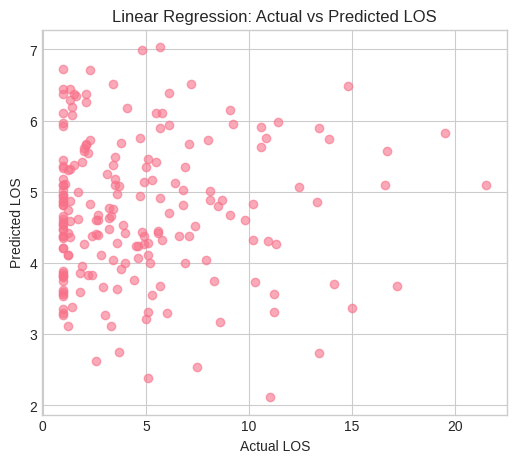

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6)
plt.xlabel("Actual LOS")
plt.ylabel("Predicted LOS")
plt.title("Linear Regression: Actual vs Predicted LOS")
plt.grid(True)
plt.show()

Show feature coefficients

In [ ]:
reg_coeffs = pd.DataFrame({
    'Feature': X_reg.columns,
    'Coefficient': lin_reg.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

reg_coeffs.head(15)

,Feature,Coefficient
17,shock_index,1.579111
24,diagnosis_Sepsis,-1.349781
21,diagnosis_Heart Failure,-1.253843
22,diagnosis_Pneumonia,-1.115867
25,diagnosis_Stroke,-0.672279
26,diagnosis_Trauma,-0.579756
23,diagnosis_Renal Failure,-0.501691
20,admission_type_URGENT,0.282398
18,gender_M,-0.274627
10,creatinine_mg_dl,-0.178152


#Task 2 — Logistic Regression
Goal: Predict Mortality

Type: Classification

Will the patient survive?

Prepare features and target

In [ ]:
X_clf = mimic_encoded.drop(columns=['patient_id', 'los_days', 'mortality'])
y_clf = mimic_encoded['mortality']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

Scale features

Logistic regression usually works better with scaling.

In [ ]:
scaler = StandardScaler()

X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)

Train model

In [ ]:
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_clf_scaled, y_train_clf)

LogisticRegression(max_iter=2000, random_state=42)

Predict class and probability

In [ ]:
y_pred_clf = log_reg.predict(X_test_clf_scaled)
y_prob_clf = log_reg.predict_proba(X_test_clf_scaled)[:, 1]

Evaluate classification model

In [ ]:
acc = accuracy_score(y_test_clf, y_pred_clf)
auc = roc_auc_score(y_test_clf, y_prob_clf)
cm = confusion_matrix(y_test_clf, y_pred_clf)

print("Logistic Regression Evaluation")
print("Accuracy:", round(acc, 3))
print("AUC     :", round(auc, 3))
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf))

Logistic Regression Evaluation
Accuracy: 0.87
AUC     : 0.518

Confusion Matrix:
[[174   0]
 [ 26   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       174
           1       0.00      0.00      0.00        26

    accuracy                           0.87       200
   macro avg       0.43      0.50      0.47       200
weighted avg       0.76      0.87      0.81       200



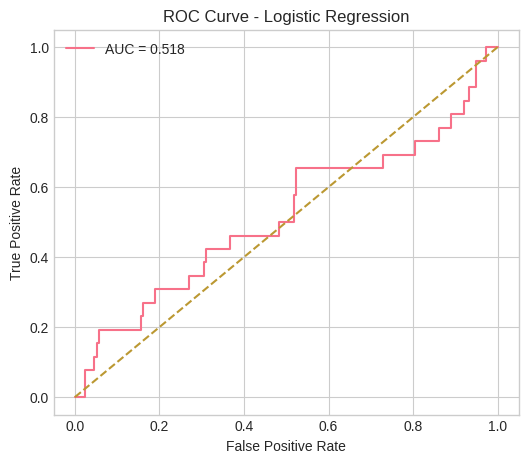

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test_clf, y_prob_clf)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
clf_coeffs = pd.DataFrame({
    'Feature': X_clf.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

clf_coeffs.head(15)

,Feature,Coefficient
1,weight_kg,0.391250
15,bmi,-0.277968
7,temperature_c,0.252557
23,diagnosis_Renal Failure,0.242994
0,age,0.212405
13,platelets_k_ul,-0.208708
22,diagnosis_Pneumonia,-0.199637
17,shock_index,-0.149690
6,respiratory_rate,0.144685
28,icu_type_SICU,0.139559


#Classification Models in Biomedical ML

What is Classification?

Predicts categories
Output:
0 = Alive
1 = Dead

Examples

- Mortality prediction

- Readmission prediction

- Disease classification


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = mimic_encoded.drop(columns=['patient_id', 'los_days', 'mortality'])
y = mimic_encoded['mortality']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaled version for models that need scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

def evaluate_model(name, y_test, y_pred, y_prob=None):
    print(f"\n=== {name} ===")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))

    if y_prob is not None:
        print("AUC:", round(roc_auc_score(y_test, y_prob), 3))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

###Decision Tree

Uses IF–THEN rules, Splits data step-by-step

IF HR > 100 AND SpO2 < 93 → high risk

Pros

- Very interpretable

- Handles non-linear relationships

Cons

- Can overfit

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_clf.fit(X_train, y_train)

y_pred_tree = tree_clf.predict(X_test)
y_prob_tree = tree_clf.predict_proba(X_test)[:, 1]

evaluate_model("Decision Tree", y_test, y_pred_tree, y_prob_tree)


=== Decision Tree ===
Accuracy: 0.875
AUC: 0.535
Confusion Matrix:
[[174   0]
 [ 25   1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       174
           1       1.00      0.04      0.07        26

    accuracy                           0.88       200
   macro avg       0.94      0.52      0.50       200
weighted avg       0.89      0.88      0.82       200



###Random Forest
Many decision trees combined, Final prediction = majority vote

Uses multiple rules to predict mortality

Pros

- High accuracy
- Handles noise well

Cons
- less interpretable

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)


=== Random Forest ===
Accuracy: 0.87
AUC: 0.529
Confusion Matrix:
[[174   0]
 [ 26   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       174
           1       0.00      0.00      0.00        26

    accuracy                           0.87       200
   macro avg       0.43      0.50      0.47       200
weighted avg       0.76      0.87      0.81       200



###Gradient Boosting
Builds trees sequentially, Each tree corrects previous errors

Pros
- Very high performance
- Widely used in healthcare ML

Cons
- More complex
- Less interpretable

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(random_state=42)
gb_clf.fit(X_train, y_train)

y_pred_gb = gb_clf.predict(X_test)
y_prob_gb = gb_clf.predict_proba(X_test)[:, 1]

evaluate_model("Gradient Boosting", y_test, y_pred_gb, y_prob_gb)


=== Gradient Boosting ===
Accuracy: 0.865
AUC: 0.524
Confusion Matrix:
[[172   2]
 [ 25   1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       174
           1       0.33      0.04      0.07        26

    accuracy                           0.86       200
   macro avg       0.60      0.51      0.50       200
weighted avg       0.80      0.86      0.82       200



### Support Vector Machines
Finds best boundary between classes, Works well in high-dimensional data

Classify patients into risk groups

Pros
- Good for complex datasets

Cons
- Hard to interpret
- Sensitive to scaling

In [ ]:
from sklearn.svm import SVC

svm_clf = SVC(kernel='rbf', probability=True, random_state=42)
svm_clf.fit(X_train_scaled, y_train)

y_pred_svm = svm_clf.predict(X_test_scaled)
y_prob_svm = svm_clf.predict_proba(X_test_scaled)[:, 1]

evaluate_model("SVM", y_test, y_pred_svm, y_prob_svm)


=== SVM ===
Accuracy: 0.87
AUC: 0.539
Confusion Matrix:
[[174   0]
 [ 26   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       174
           1       0.00      0.00      0.00        26

    accuracy                           0.87       200
   macro avg       0.43      0.50      0.47       200
weighted avg       0.76      0.87      0.81       200



###KNN
Predict based on nearest patients, Uses similarity

KNN assumes similar patients have similar outcomes.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)

y_pred_knn = knn_clf.predict(X_test_scaled)
y_prob_knn = knn_clf.predict_proba(X_test_scaled)[:, 1]

evaluate_model("KNN", y_test, y_pred_knn, y_prob_knn)


=== KNN ===
Accuracy: 0.855
AUC: 0.521
Confusion Matrix:
[[171   3]
 [ 26   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       174
           1       0.00      0.00      0.00        26

    accuracy                           0.85       200
   macro avg       0.43      0.49      0.46       200
weighted avg       0.76      0.85      0.80       200



### Neural Network

Multi-layer models, Learn complex patterns, Mortality prediction using all features

Pros
- Handles complex data
- High performance

Cons
- Needs more data
- Less interpretable

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

tf.keras.backend.clear_session()

nn_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

y_prob_nn = nn_model.predict(X_test_scaled).flatten()
y_pred_nn = (y_prob_nn > 0.5).astype(int)

evaluate_model("Neural Network", y_test, y_pred_nn, y_prob_nn)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5953 - loss: 0.6654 - val_accuracy: 0.7812 - val_loss: 0.5455
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8531 - loss: 0.4841 - val_accuracy: 0.8562 - val_loss: 0.4525
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8750 - loss: 0.4072 - val_accuracy: 0.8562 - val_loss: 0.4309
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8750 - loss: 0.3809 - val_accuracy: 0.8562 - val_loss: 0.4296
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8750 - loss: 0.3676 - val_accuracy: 0.8562 - val_loss: 0.4310
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8750 - loss: 0.3601 - val_accuracy: 0.8562 - val_loss: 0.4307
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8750 - loss: 0.3530 - val_accuracy: 0.8562 - val_loss: 0.4298
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8750 - loss: 0.3470 - val_accuracy: 0.8562 - val_loss

In [ ]:
results = []

def store_results(name, y_test, y_pred, y_prob):
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "AUC": round(roc_auc_score(y_test, y_prob), 3)
    })

#store_results("Logistic Regression", y_test, y_pred_log, y_prob_log)
store_results("Decision Tree", y_test, y_pred_tree, y_prob_tree)
store_results("Random Forest", y_test, y_pred_rf, y_prob_rf)
store_results("Gradient Boosting", y_test, y_pred_gb, y_prob_gb)
store_results("SVM", y_test, y_pred_svm, y_prob_svm)
store_results("KNN", y_test, y_pred_knn, y_prob_knn)
#store_results("Naive Bayes", y_test, y_pred_nb, y_prob_nb)
#store_results("XGBoost", y_test, y_pred_xgb, y_prob_xgb)
store_results("Neural Network", y_test, y_pred_nn, y_prob_nn)

results_df = pd.DataFrame(results).sort_values(by="AUC", ascending=False)
results_df

,Model,Accuracy,AUC
3,SVM,0.870,0.539
0,Decision Tree,0.875,0.535
1,Random Forest,0.870,0.529
5,Neural Network,0.865,0.525
2,Gradient Boosting,0.865,0.524
4,KNN,0.855,0.521


#Regression Models

Linear Regression

Predicts LOS using a straight-line relationship.

Ridge Regression

Improves stability when features are correlated.

Lasso Regression

Selects important features by shrinking some coefficients to zero.

Decision Tree Regressor

Learns rule-based splits for LOS prediction.

Random Forest Regressor

Combines many trees for more stable predictions.

Gradient Boosting / XGBoost

Improves prediction step by step by correcting earlier errors.

Neural Network Regressor

Learns complex non-linear relationships in the data.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X_reg = mimic_encoded.drop(columns=['patient_id', 'los_days', 'mortality'])
y_reg = mimic_encoded['los_days']

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Scaled version for models that need scaling
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_regression_model(name, y_test, y_pred):
    print(f"\n=== {name} ===")
    print("MAE :", round(mean_absolute_error(y_test, y_pred), 3))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 3))
    print("R2  :", round(r2_score(y_test, y_pred), 3))

In [ ]:

from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train_reg_scaled, y_train_reg)

y_pred_ridge = ridge_reg.predict(X_test_reg_scaled)

evaluate_regression_model("Ridge Regression", y_test_reg, y_pred_ridge)


=== Ridge Regression ===
MAE : 3.268
RMSE: 4.213
R2  : -0.055


In [ ]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.05)
lasso_reg.fit(X_train_reg_scaled, y_train_reg)

y_pred_lasso = lasso_reg.predict(X_test_reg_scaled)

evaluate_regression_model("Lasso Regression", y_test_reg, y_pred_lasso)


=== Lasso Regression ===
MAE : 3.22
RMSE: 4.152
R2  : -0.025


In [ ]:
from sklearn.linear_model import ElasticNet

elastic_reg = ElasticNet(alpha=0.05, l1_ratio=0.5, random_state=42)
elastic_reg.fit(X_train_reg_scaled, y_train_reg)

y_pred_elastic = elastic_reg.predict(X_test_reg_scaled)

evaluate_regression_model("Elastic Net", y_test_reg, y_pred_elastic)


=== Elastic Net ===
MAE : 3.226
RMSE: 4.163
R2  : -0.03


In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_reg.fit(X_train_reg, y_train_reg)

y_pred_tree_reg = tree_reg.predict(X_test_reg)

evaluate_regression_model("Decision Tree Regressor", y_test_reg, y_pred_tree_reg)


=== Decision Tree Regressor ===
MAE : 3.314
RMSE: 4.342
R2  : -0.121


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)

y_pred_rf_reg = rf_reg.predict(X_test_reg)

evaluate_regression_model("Random Forest Regressor", y_test_reg, y_pred_rf_reg)


=== Random Forest Regressor ===
MAE : 3.552
RMSE: 4.382
R2  : -0.142


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train_reg, y_train_reg)

y_pred_gb_reg = gb_reg.predict(X_test_reg)

evaluate_regression_model("Gradient Boosting Regressor", y_test_reg, y_pred_gb_reg)


=== Gradient Boosting Regressor ===
MAE : 3.421
RMSE: 4.446
R2  : -0.175


In [ ]:
from sklearn.svm import SVR

svr_reg = SVR(kernel='rbf')
svr_reg.fit(X_train_reg_scaled, y_train_reg)

y_pred_svr = svr_reg.predict(X_test_reg_scaled)

evaluate_regression_model("Support Vector Regressor", y_test_reg, y_pred_svr)


=== Support Vector Regressor ===
MAE : 3.044
RMSE: 4.301
R2  : -0.1


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_reg_scaled, y_train_reg)

y_pred_knn_reg = knn_reg.predict(X_test_reg_scaled)

evaluate_regression_model("KNN Regressor", y_test_reg, y_pred_knn_reg)


=== KNN Regressor ===
MAE : 3.514
RMSE: 4.448
R2  : -0.177


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_reg.fit(X_train_reg, y_train_reg)

y_pred_xgb_reg = xgb_reg.predict(X_test_reg)

evaluate_regression_model("XGBoost Regressor", y_test_reg, y_pred_xgb_reg)


=== XGBoost Regressor ===
MAE : 3.369
RMSE: 4.317
R2  : -0.108


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

tf.keras.backend.clear_session()

nn_reg = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_reg_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

nn_reg.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

nn_reg.fit(
    X_train_reg_scaled, y_train_reg,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

y_pred_nn_reg = nn_reg.predict(X_test_reg_scaled).flatten()

evaluate_regression_model("Neural Network Regressor", y_test_reg, y_pred_nn_reg)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 57.3058 - mae: 5.7791 - val_loss: 36.4433 - val_mae: 4.5841
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 45.7419 - mae: 4.7296 - val_loss: 28.9143 - val_mae: 3.7130
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 37.8894 - mae: 3.9570 - val_loss: 23.5914 - val_mae: 3.1951
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 32.0332 - mae: 3.5123 - val_loss: 19.8826 - val_mae: 2.9422
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 27.9504 - mae: 3.3264 - val_loss: 17.7695 - val_mae: 2.8247
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 25.3634 - mae: 3.3324 - val_loss: 16.9424 - val_mae: 2.8325
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 23.8818 - mae: 3.3516 - val_loss: 16.7954 - val_mae: 2.8952
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 23.0396 - mae: 3.3741 - val_loss: 16.8422 - val_mae: 2.9451
Epoch 9/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/st

In [ ]:
regression_results = []

def store_regression_results(name, y_test, y_pred):
    regression_results.append({
        "Model": name,
        "MAE": round(mean_absolute_error(y_test, y_pred), 3),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
        "R2": round(r2_score(y_test, y_pred), 3)
    })

#store_regression_results("Linear Regression", y_test_reg, y_pred_lin)
store_regression_results("Ridge Regression", y_test_reg, y_pred_ridge)
store_regression_results("Lasso Regression", y_test_reg, y_pred_lasso)
store_regression_results("Elastic Net", y_test_reg, y_pred_elastic)
store_regression_results("Decision Tree Regressor", y_test_reg, y_pred_tree_reg)
store_regression_results("Random Forest Regressor", y_test_reg, y_pred_rf_reg)
store_regression_results("Gradient Boosting Regressor", y_test_reg, y_pred_gb_reg)
store_regression_results("SVR", y_test_reg, y_pred_svr)
store_regression_results("KNN Regressor", y_test_reg, y_pred_knn_reg)
store_regression_results("XGBoost Regressor", y_test_reg, y_pred_xgb_reg)
store_regression_results("Neural Network Regressor", y_test_reg, y_pred_nn_reg)

regression_results_df = pd.DataFrame(regression_results).sort_values(by="RMSE")
regression_results_df

,Model,MAE,RMSE,R2
1,Lasso Regression,3.220,4.152,-0.025
2,Elastic Net,3.226,4.163,-0.030
0,Ridge Regression,3.268,4.213,-0.055
6,SVR,3.044,4.301,-0.100
8,XGBoost Regressor,3.369,4.317,-0.108
3,Decision Tree Regressor,3.314,4.342,-0.121
9,Neural Network Regressor,3.413,4.370,-0.135
4,Random Forest Regressor,3.552,4.382,-0.142
5,Gradient Boosting Regressor,3.421,4.446,-0.175
7,KNN Regressor,3.514,4.448,-0.177


#EXAMPLES

###LSTM for Time-Series ICU Vitals
Handles sequences, Captures trends over time

Use LSTM when each patient has measurements over time, not just one row.

Example:

heart rate every hour for 24 hours
BP every hour
SpO2 every hour

Goal:

predict mortality from the first 24 hours of ICU signals

Create synthetic time-series ICU data

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_patients = 1000
time_steps = 24
n_features = 4

X_seq = np.zeros((n_patients, time_steps, n_features))
y_seq = np.zeros(n_patients)

for i in range(n_patients):
    age = np.random.randint(18, 95)

    hr_base = np.random.normal(85, 10)
    sbp_base = np.random.normal(125, 15)
    rr_base = np.random.normal(18, 3)
    spo2_base = np.random.normal(96, 2)

    mortality_risk = 0

    for t in range(time_steps):
        hr = hr_base + np.random.normal(0, 5)
        sbp = sbp_base + np.random.normal(0, 6)
        rr = rr_base + np.random.normal(0, 2)
        spo2 = spo2_base + np.random.normal(0, 1.5)

        # make some patients deteriorate over time
        if np.random.rand() < 0.15:
            hr += t * 0.8
            sbp -= t * 0.7
            rr += t * 0.3
            spo2 -= t * 0.2
            mortality_risk += 1

        X_seq[i, t, 0] = hr
        X_seq[i, t, 1] = sbp
        X_seq[i, t, 2] = rr
        X_seq[i, t, 3] = spo2

    # mortality label
    y_seq[i] = 1 if (mortality_risk > 8 or age > 80 and np.random.rand() < 0.3) else 0

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)
print("Mortality rate:", y_seq.mean())

X_seq shape: (1000, 24, 4)
y_seq shape: (1000,)
Mortality rate: 0.059


Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)

Scale the sequence data

In [ ]:
from sklearn.preprocessing import StandardScaler

scalers = []
X_train_seq_scaled = X_train_seq.copy()
X_test_seq_scaled = X_test_seq.copy()

for f in range(n_features):
    scaler = StandardScaler()
    X_train_seq_scaled[:, :, f] = scaler.fit_transform(X_train_seq[:, :, f])
    X_test_seq_scaled[:, :, f] = scaler.transform(X_test_seq[:, :, f])
    scalers.append(scaler)

Build LSTM model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential([
    LSTM(32, input_shape=(time_steps, n_features)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,281 (20.63 KB)

 Trainable params: 5,281 (20.63 KB)

 Non-trainable params: 0 (0.00 B)

Train model

In [ ]:
history = lstm_model.fit(
    X_train_seq_scaled,
    y_train_seq,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    verbose=1
)

Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.2500 - loss: 0.7662 - val_accuracy: 0.6187 - val_loss: 0.6734
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7563 - loss: 0.6357 - val_accuracy: 0.9375 - val_loss: 0.5734
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9250 - loss: 0.4992 - val_accuracy: 0.9500 - val_loss: 0.3683
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9391 - loss: 0.2765 - val_accuracy: 0.9500 - val_loss: 0.1972
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9391 - loss: 0.2327 - val_accuracy: 0.9500 - val_loss: 0.1975
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9391 - loss: 0.2297 - val_accuracy: 0.9500 - val_loss: 0.1975
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9391 - loss: 0.2298 - val_accuracy: 0.9500 - val_loss: 0.1981
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9391 - loss: 0.2251 - val_accuracy: 0.9500 - v

Evaluate

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

y_prob_seq = lstm_model.predict(X_test_seq_scaled).flatten()
y_pred_seq = (y_prob_seq > 0.5).astype(int)

print("LSTM Accuracy:", round(accuracy_score(y_test_seq, y_pred_seq), 3))
print("LSTM AUC:", round(roc_auc_score(y_test_seq, y_prob_seq), 3))
print(confusion_matrix(y_test_seq, y_pred_seq))
print(classification_report(y_test_seq, y_pred_seq))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
LSTM Accuracy: 0.94
LSTM AUC: 0.468
[[188   0]
 [ 12   0]]
              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97       188
         1.0       0.00      0.00      0.00        12

    accuracy                           0.94       200
   macro avg       0.47      0.50      0.48       200
weighted avg       0.88      0.94      0.91       200



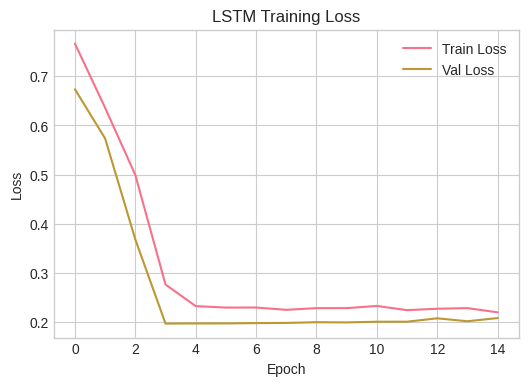

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

###Autoencoder for Representation Learning

An autoencoder learns a compressed version of the patient data.

Use case:

reduce many features into a few latent features
then use those compressed features for clustering or classification

tabular MIMIC-like dataset

In [ ]:
# drop targets and ID
X_auto = mimic_encoded.drop(columns=['patient_id', 'los_days', 'mortality'])

from sklearn.preprocessing import StandardScaler
scaler_auto = StandardScaler()
X_auto_scaled = scaler_auto.fit_transform(X_auto)

print(X_auto_scaled.shape)

Build autoencoder

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_auto_scaled.shape[1]
encoding_dim = 8

input_layer = Input(shape=(input_dim,))
encoded = Dense(16, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu', name='latent_space')(encoded)

decoded = Dense(16, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Train autoencoder

In [ ]:
history_auto = autoencoder.fit(
    X_auto_scaled, X_auto_scaled,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Extract compressed features

In [ ]:
encoder = Model(inputs=autoencoder.input,
                outputs=autoencoder.get_layer('latent_space').output)

X_latent = encoder.predict(X_auto_scaled)

print("Original shape:", X_auto_scaled.shape)
print("Compressed shape:", X_latent.shape)

Use latent features for mortality prediction

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

y_auto = mimic_encoded['mortality']

X_train_lat, X_test_lat, y_train_lat, y_test_lat = train_test_split(
    X_latent, y_auto, test_size=0.2, random_state=42, stratify=y_auto
)

clf_latent = LogisticRegression(max_iter=1000)
clf_latent.fit(X_train_lat, y_train_lat)

y_prob_lat = clf_latent.predict_proba(X_test_lat)[:, 1]
y_pred_lat = clf_latent.predict(X_test_lat)

print("Latent-feature Accuracy:", round(accuracy_score(y_test_lat, y_pred_lat), 3))
print("Latent-feature AUC:", round(roc_auc_score(y_test_lat, y_prob_lat), 3))

Visualize latent space

If encoding dim is 2, it is easy to plot. If it is 8, use PCA.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler

# reset session to avoid buildup from repeated reruns
tf.keras.backend.clear_session()

# prepare input
X_auto = mimic_encoded.drop(columns=['patient_id', 'los_days', 'mortality'])
scaler_auto = StandardScaler()
X_auto_scaled = scaler_auto.fit_transform(X_auto).astype("float32")

# model
input_dim = X_auto_scaled.shape[1]
encoding_dim = 8

input_layer = Input(shape=(input_dim,))
encoded = Dense(16, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu', name='latent_space')(encoded)

decoded = Dense(16, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# train
history_auto = autoencoder.fit(
    X_auto_scaled,
    X_auto_scaled,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# encoder
encoder = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer('latent_space').output
)

# predict once
X_latent = encoder.predict(X_auto_scaled, verbose=0)

print("Original shape:", X_auto_scaled.shape)
print("Compressed shape:", X_latent.shape)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

y_auto = mimic_encoded['mortality']

X_train_lat, X_test_lat, y_train_lat, y_test_lat = train_test_split(
    X_latent, y_auto, test_size=0.2, random_state=42, stratify=y_auto
)

clf_latent = LogisticRegression(max_iter=1000)
clf_latent.fit(X_train_lat, y_train_lat)

y_prob_lat = clf_latent.predict_proba(X_test_lat)[:, 1]
y_pred_lat = clf_latent.predict(X_test_lat)

print("Latent-feature Accuracy:", round(accuracy_score(y_test_lat, y_pred_lat), 3))
print("Latent-feature AUC:", round(roc_auc_score(y_test_lat, y_prob_lat), 3))

###Survival Analysis for Time-to-Event Modeling

Regression predicts a number.
Classification predicts yes/no.
Survival analysis predicts:

when an event may happen
while handling censored patients

Example:

time until death
time until ICU discharge
time until readmission

This is especially useful when some patients are still alive at the end of follow-up.

In [ ]:
!pip install lifelines

Create synthetic survival dataset

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 1000

survival_data = pd.DataFrame({
    'age': np.random.normal(65, 15, n).clip(18, 95).astype(int),
    'creatinine': np.random.exponential(1.2, n).clip(0.5, 8).round(2),
    'heart_rate': np.random.normal(85, 18, n).clip(40, 180).astype(int),
    'spo2': np.random.normal(96, 3, n).clip(70, 100).astype(int)
})

# risk score
risk_score = (
    0.03 * survival_data['age'] +
    0.5 * survival_data['creatinine'] +
    0.02 * survival_data['heart_rate'] -
    0.08 * survival_data['spo2']
)

# shorter survival time for higher risk
survival_data['time_to_event'] = np.maximum(
    1,
    np.random.exponential(scale=20, size=n) / np.exp(risk_score / 8)
).round(1)

# censoring: some patients do not experience event
survival_data['event_observed'] = np.random.binomial(1, 0.7, size=n)

survival_data.head()

,age,creatinine,heart_rate,spo2,time_to_event,event_observed
0,72,0.50,79,93,4.0,0
1,62,0.50,71,92,32.5,1
2,74,1.21,90,94,3.8,1
3,87,1.47,109,96,1.9,1
4,61,0.50,51,97,86.0,1


Kaplan-Meier curve

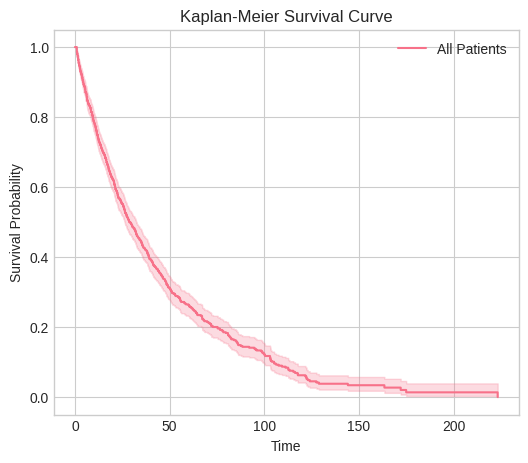

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(6,5))
kmf.fit(
    durations=survival_data['time_to_event'],
    event_observed=survival_data['event_observed'],
    label='All Patients'
)
kmf.plot_survival_function()
plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

Compare high-risk vs low-risk groups

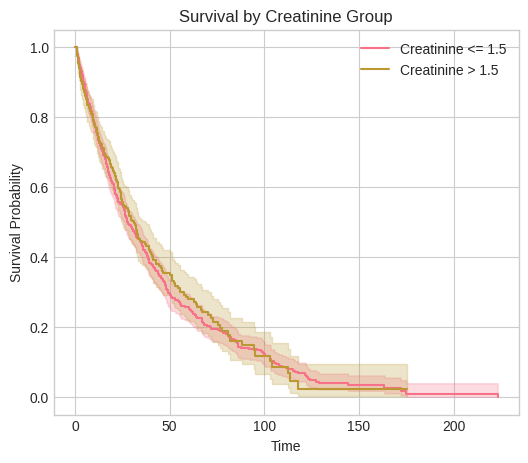

In [ ]:
survival_data['high_creatinine'] = (survival_data['creatinine'] > 1.5).astype(int)

plt.figure(figsize=(6,5))

for group, label in [(0, 'Creatinine <= 1.5'), (1, 'Creatinine > 1.5')]:
    mask = survival_data['high_creatinine'] == group
    kmf.fit(
        durations=survival_data.loc[mask, 'time_to_event'],
        event_observed=survival_data.loc[mask, 'event_observed'],
        label=label
    )
    kmf.plot_survival_function()

plt.title("Survival by Creatinine Group")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

Cox Proportional Hazards model

In [ ]:
from lifelines import CoxPHFitter

cox_df = survival_data[['time_to_event', 'event_observed', 'age', 'creatinine', 'heart_rate', 'spo2']]

cph = CoxPHFitter()
cph.fit(cox_df, duration_col='time_to_event', event_col='event_observed')

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1000 total observations, 301 right-censored observations>
             duration col = 'time_to_event'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 1000
number of events observed = 699
   partial log-likelihood = -4142.90
         time fit was run = 2026-04-17 05:08:28 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
age         0.00      1.00      0.00           -0.01            0.01                0.99                1.01
creatinine -0.02      0.98      0.04           -0.09            0.06                0.92                1.06
heart_rate  0.00      1.00      0.00            0.00            0.01                1.00                1.01
spo2       -0.01      0.99      0.01           -0.04            0.01                0.96                1.01

            cmp to     z    p  -log2(p)
covariate                              
age           0.00  0.05 0.96      0.06
creatinine    0.00 -0.44 0.66      0.60
heart_rate    0.00  2.20 0.03      5.17
spo2          0.00 -0.85 0.39      1.35
---
Concordance = 0.53
Partial AIC = 8293.80
log-likelihood ratio test = 5.56 on 4 df
-log2(p) of ll-ratio test = 2.09

Interpret hazard ratios

In [ ]:
cph.summary[['coef', 'exp(coef)', 'p']]

,coef,exp(coef),p
covariate,,,
age,0.000127,1.000127,0.962425
creatinine,-0.015917,0.984209,0.661263
heart_rate,0.004581,1.004592,0.027701
spo2,-0.011073,0.988988,0.393527


Plot partial effects

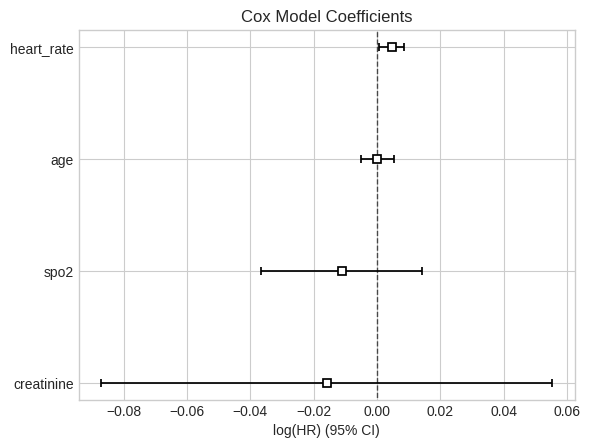

In [ ]:
cph.plot()
plt.title("Cox Model Coefficients")
plt.grid(True)
plt.show()